In [2]:
import os
#скачиваем библиотеку для поиска файлов
print(os.listdir("/home/jupyter/s3"))
#Полностью скрываем GPU
os.environ["CUDA_VISIBLE_DEVICES"] = ""
# Ограничиваем количество CPU-потоков
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

['neuro-data']


In [3]:
DATA_PATH = "/home/jupyter/s3/neuro-data"
#создаем переменную, в которой есть путь к нашему датасету 
#далее хотели узнать структуру данных: вывели первые 50 элементов
print(os.listdir(DATA_PATH)[:50])

['Норма', 'ПТСР', 'Соматоформные']


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne

**Структура выборки**

In [5]:
groups = ['Норма', 'ПТСР', 'Соматоформные'] #названия 3 классов из нашего датасета
file_stats = {} #здесь будем хранить кол-во испытуемых
for group in groups:
    #переходим к каждой группе
    group_path = os.path.join(DATA_PATH, group)
    files = os.listdir(group_path)
    #получаем путь к конкретной папке группы
    file_stats[group] = len(files)
    #считаем кол-во испытуемых в каждой группе, выводим первые 3 объекта каждой группы
    print(group)
    print(len(files))
    #print((set([f.split('.')[-1] for f in files])))
    print(files[:3])

Норма
90
['A003_68', 'A032_65', 'A036_69']
ПТСР
25
['34PHG', 'BGVF', 'DFGH']
Соматоформные
74
['ABXZ5', 'ASDF9', 'BCRX1']


In [6]:
subjects_data = []
#создаем таблицу испытуемых, куда будем добавлять: id испытуемого, его принадлежность, возраст, общее кол-во файлов, наличие записей покоя и с таблицами Шульте
for group in groups:
    group_path = os.path.join(DATA_PATH, group)
    for subj in os.listdir(group_path):
        subj_path = os.path.join(group_path, subj)
        #защитная проверка, действительно ли это папка
        if os.path.isdir(subj_path):
            files = os.listdir(subj_path)
            #заходим внутрь папки конкретного испытуемого
            age = None #пока возраст неизвестен
            if group == 'Норма' and '_' in subj: #предполагаем, что в id содердится и информация о возрасте участника, данные представлены в формате: id_age
                parts = subj.split('_')
                if parts[-1].isdigit():
                    age = int(parts[-1])
            #ищем запись покоя, если заканчивается на P или П, то это запись в сотсоянии покоя
            has_rest = any(f.endswith('-П.edf') or f.endswith('-P.edf') for f in files) 
            #считаем, кол-во записей при выполнении таблиц Шульта для каждого участника
            schulte_count = sum(1 for f in files if any(f.endswith(f'-{i}.edf') for i in range(1, 6)))
            #добавляем результаты по каждому человеку
            subjects_data.append({
                'subject_id': subj,
                'group': group,
                'age': age,
                'total_files': len(files),
                'has_rest': has_rest,
                'n_schulte': schulte_count
            })
#выводим получившуюся таблицу
df_summary = pd.DataFrame(subjects_data)
print(df_summary.groupby('group').agg(subjects_count=('subject_id', 'count'),has_rest_count=('has_rest', 'sum'),avg_schulte_files=('n_schulte', 'mean'),age_known=('age', lambda x: x.notnull().sum())))

               subjects_count  has_rest_count  avg_schulte_files  age_known
group                                                                      
Норма                      90              90           3.977778         90
ПТСР                       25              25           5.000000          0
Соматоформные              74              74           5.000000          0


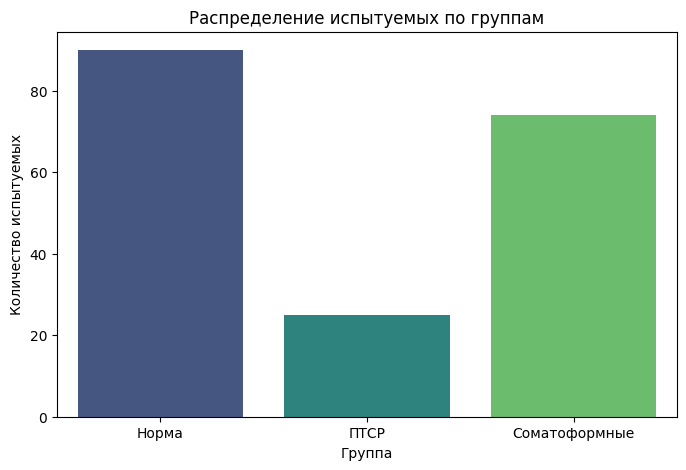

In [7]:
subject_counts = (df_summary['group'].value_counts().reindex(groups))
plt.figure(figsize=(8, 5))
sns.barplot(x=subject_counts.index, y=subject_counts.values, palette='viridis')
plt.xlabel('Группа')
plt.ylabel('Количество испытуемых')
plt.title('Распределение испытуемых по группам')
plt.show()

 В представленном датасете было обнаружено 166 испытуемых, которые были распределены по 3 диагностическим группам: 67 человек в группе "Норма", 25 в группе "ПТСР" и 74 в группе соматоформных расстройств, что совпадает с данными из описания участников (описания задачи).  Наличие 3 группы, "Соматоформные расстройства", позволяет сравнить не только отличие ПТСР от нормы, но и ПТСР от другой клинической группы. В дальнейшем это может помочь нам выявить паттерны, характерные именно для ПТСР. Из результатов подсчета кол-ва участников в каждой из групп, видно, что выборка является несбалансированной по целевому классу. Для каждого испытуемого была обнаружена одна фоновая запись состояния покоя и пять записей последовательного выполнения таблиц Шульте.
 Экспериментальный дизайн позволяет анализировать не только абсолютные характеристики EEG, но и реакцию на когнитивную нагрузку относительно индивидуального фонового состояния. Например, в дальнейшем можно сравнивать спектральные характеристики EEG в покое и во время таблиц Шульте и рассчитывать абсолютные или относительные изменения признаков относительно фоновой записи. В названиях группы нормы присутствует числовой компонент после символа _ (например, КС010_19). В текущем коде он интерпретируется как возраст, благодаря чему значение было получено для всех 67 испытуемых контрольной группы. Для групп ПТСР и соматоформных расстройств возраст из идентификаторов определить не удалось. Поэтому на текущем этапе невозможно полноценно проверить, различаются ли диагностические группы по возрасту и не будет ли являться возраст потенциальным источником наблюдаемых EEG-различий

**Проверка состава ЭЭГ-каналов и технических характеристик данных**

In [8]:
import warnings

In [9]:
mne.set_log_level('ERROR')

In [10]:
#создаем функцию, которая будет получать доступ к одному файлу и извлекать из него важную информацию
def safe_get_edf_info(filepath):
    """
    Читает только заголовок EDF без загрузки сигнала в память.
    """
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            raw = mne.io.read_raw_edf(
                filepath,
                preload=False, #preload=False, тк из самого файла нам пока нужен только заголовок
                verbose="ERROR"
            )
        sfreq = raw.info['sfreq'] #частота дискретизации
        duration = (              #получаем длительность записи делением кол-ва отсчетов на частоту дискретизации
            raw.n_times /
            sfreq
        )
        channels = raw.ch_names   #получаем названия всех сигналов из файла (часть из них может не относиться к ЭЭГ-каналам)

        result = {
            'sfreq': sfreq,
            'duration': duration,
            'channels': channels,
            'num_channels': len(channels)
        }

        del raw

        return result

    except Exception:
        return None

In [11]:
file_stats = []
corrupted_files = []
#отедльно записываем нормальные файлы и те, с которыми функция не справилась
for group in groups: #перебираем диагностические группы
    group_dir = os.path.join(DATA_PATH, group)
    if not os.path.exists(group_dir):
        continue
    #теперь перебираем испытуемых
    for subj in os.listdir(group_dir):
        subj_dir = os.path.join(group_dir, subj)
        if not os.path.isdir(subj_dir):
            continue
            #файлы конкретного испытуемого
        for fname in os.listdir(subj_dir):
            if fname.endswith('.edf'):
                fpath = os.path.join(subj_dir, fname)
                info = safe_get_edf_info(fpath)
                #если файл не удалось прочитать:
                if info is None:
                    corrupted_files.append((group, subj, fname))
                    continue
                #извлекаем всю информацию, которую ищет наша функция
                is_rest = '-П' in fname or '-P' in fname #ищем файлы с записями покоя
                file_stats.append({
                    'subject_id': subj,
                    'group': group,
                    'file_name': fname,
                    'path' : fpath,
                    'file_type': 'Покой' if is_rest else 'Шульте',
                    'sfreq': info['sfreq'],
                    'duration_sec': info['duration'],
                    'num_channels': info['num_channels'],
                    'channels_str': ",".join(info['channels'])
                })

df_files = pd.DataFrame(file_stats)

sample_freqs = df_files['sfreq'].unique()
channel_counts = df_files['num_channels'].unique()
is_channels_identical = (df_files['channels_str'].nunique() == 1)

print(f"Частота дискретизации: {sample_freqs} Гц")
print(f"Количество каналов в файлах: {channel_counts}")
print(f"Набор каналов одинаков для всех записей: {is_channels_identical}")
print(f"Названия каналов: {df_files['channels_str'].iloc[0]}")
print('Не удалось прочитать EDF-файлов:', len(corrupted_files))
for group, subj, fname in corrupted_files:
    print(group, subj, fname)

Частота дискретизации: [125. 126. 127. 123. 124.] Гц
Количество каналов в файлах: [6]
Набор каналов одинаков для всех записей: True
Названия каналов: O1,T3,Fp1,Fp2,T4,O2
Не удалось прочитать EDF-файлов: 5
Соматоформные XCFU5 T-1.edf
Соматоформные XCFU5 T-2.edf
Соматоформные XCFU5 T-3.edf
Соматоформные XCFU5 T-4.edf
Соматоформные XCFU5 T-5.edf


In [13]:
#далее посмотрели, какие частоты дискретизации встречаются, так как в описании данных было сказано, что нет константной частоты
sfreq_table = pd.crosstab(
    df_files['group'],
    df_files['sfreq']
)
display(sfreq_table)

sfreq,123.0,124.0,125.0,126.0,127.0
group,,,,,
Норма,47,52,240,58,51
ПТСР,0,0,150,0,0
Соматоформные,0,0,439,0,0


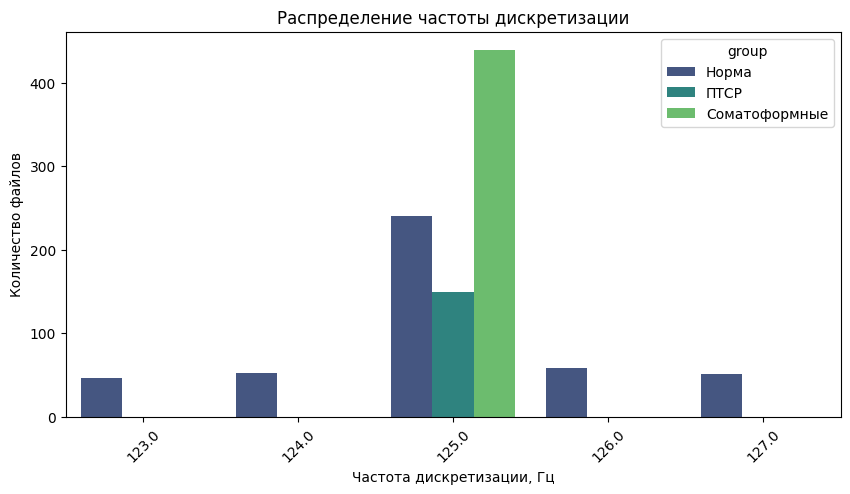

In [14]:
#далее попытались определить, у участников какой группы какие частоты дискретизации встречаются чаще 
plt.figure(figsize=(10, 5))

sns.countplot(data=df_files,x='sfreq',hue='group', palette='viridis')
plt.xlabel('Частота дискретизации, Гц')
plt.ylabel('Количество файлов')
plt.title('Распределение частоты дискретизации')
plt.xticks(rotation=45)

plt.show()

In [15]:
#ищем пропуски 
print('Пропуски в df_summary:')
display(df_summary.isna().sum().to_frame('n_missing'))

print('Пропуски в df_files:')
display(df_files.isna().sum().to_frame('n_missing'))

Пропуски в df_summary:


,n_missing
subject_id,0
group,0
age,99
total_files,0
has_rest,0
n_schulte,0


Пропуски в df_files:


,n_missing
subject_id,0
group,0
file_name,0
path,0
file_type,0
sfreq,0
duration_sec,0
num_channels,0
channels_str,0


Было обнаружено 6 EEG-каналов: Fp1 и Fp2, фронтополярные; Т3 и Т4, височные области; О1 и О2, затылочные области, что совпадает с описанием датасета. Ранее различия в этих регионах между здоровыми испытуемыми и людьми с подтвержденным диагнозом уже описывались, однако результаты исследований не однородны. [1][2] Наиболее часто втсречающаяся частота дискретизации = 125 Гц, остальные значения варьируется в узком диапазоне 123-127 Гц. 

In [16]:
EEG_CHANNELS = [
    'O1',
    'T3',
    'Fp1',
    'Fp2',
    'T4',
    'O2'
]

In [17]:
signal_quality = []
for idx, row in df_files.iterrows():
    try:
        raw = mne.io.read_raw_edf(
            row['path'],
            preload=True,
            verbose="Error"
        )
        raw.pick(EEG_CHANNELS) #оставляем только 6 ЭЭГ-каналов
        data = raw.get_data() #получаем сами значения ЭЭГ
        signal_quality.append({
            'subject_id': row['subject_id'],
            'group': row['group'],
            'file_name': row['file_name'],
            'file_type': row['file_type'],
            'n_samples': data.size,
            'n_nan': np.isnan(data).sum(),
            'n_inf': np.isinf(data).sum(),
            'nan_percent': np.isnan(data).mean() * 100,
            'inf_percent': np.isinf(data).mean() * 100
        })

    except Exception as e:
        print('Ошибка:', row['path'], e)

df_signal_quality = pd.DataFrame(signal_quality)


In [18]:
display(
    df_signal_quality[
        (df_signal_quality['n_nan'] > 0) |
        (df_signal_quality['n_inf'] > 0)
    ]
)

,subject_id,group,file_name,file_type,n_samples,n_nan,n_inf,nan_percent,inf_percent


Проверили данные на наличие пропущенных значений, в таблице испытуемых пропуски были обнаружена только в графе возраст, так как данные об этом показателе доступны только для группы "Норма". Отдельно были найдены 5 файлов, которые прочитать не удалось. Как видно из вывода, все эти файлы относятся к выполнению таблицы Шульте одного испытуемого из группы соматоформных расстройств, они не вошли в df_files, его запись покоя доступна. 
 Частота дисркетизации записей варьируется в диапазоне 123-127 Гц, наиболее часто встречается значение 125. Распределение частоты дискретизации различается между диагностическими группами: колебание 123–127 Гц чаще наблюдается в контрольной группе. Это указывает на возможную связь технических параметров записи с принадлежностью к группе, частота дискретизации может быть одним из возможных кофаундеров. 

**Примеры записи для каждой диагностической группы, при покое и при выполнении таблиц**

In [19]:
#в данном разделе решили визуализировать пример записи из файлов
def plot_eeg_example(filepath, title, duration=5):
    raw = mne.io.read_raw_edf(
        filepath,
        preload=True,
        verbose=False
    )
    #оставляем только ээг-каналы
    raw.pick(EEG_CHANNELS)
    data = raw.get_data() * 1e6 #переводим полученные значения в микровольты
    sfreq = raw.info['sfreq'] #получаем частоту дискретизации и названия каналов
    channels = raw.ch_names
    #определяем, где кол-во отсчетов соответствует нужной длительности
    n_samples = min(
        int(duration * sfreq),
        data.shape[1]
    )
    data = data[:, :n_samples] #оставляем только часть заданной длительности
    time = np.arange(n_samples) / sfreq #создаем временную ось в секундах
    #центрируем каждый канал относительно его медианы
    data = data - np.median(data, axis=1, keepdims=True)
    #автоматически подбираем расстояние между каналами
    scale = np.nanpercentile(np.abs(data), 95)
    if scale == 0:
        scale = 100
    offset = scale * 3
    plt.figure(figsize=(14, 6))

    for i, ch in enumerate(channels):
        plt.plot(
            time,
            data[i] + i * offset,
            linewidth=0.8
        )
    plt.yticks(
        np.arange(len(channels)) * offset,
        channels
    )
    plt.xlabel('Время, с')
    plt.ylabel('Канал')
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()

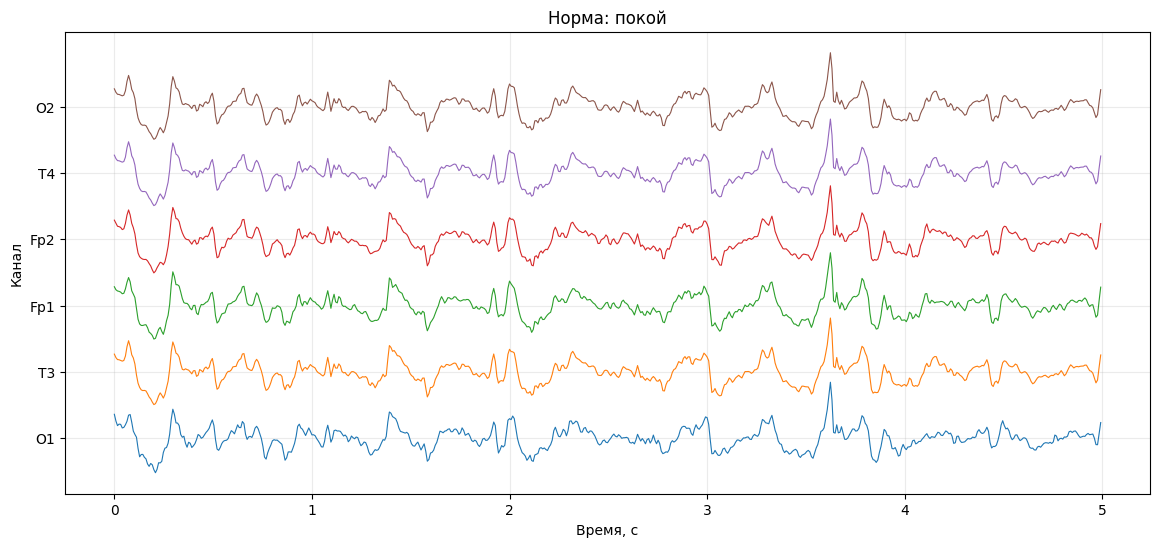

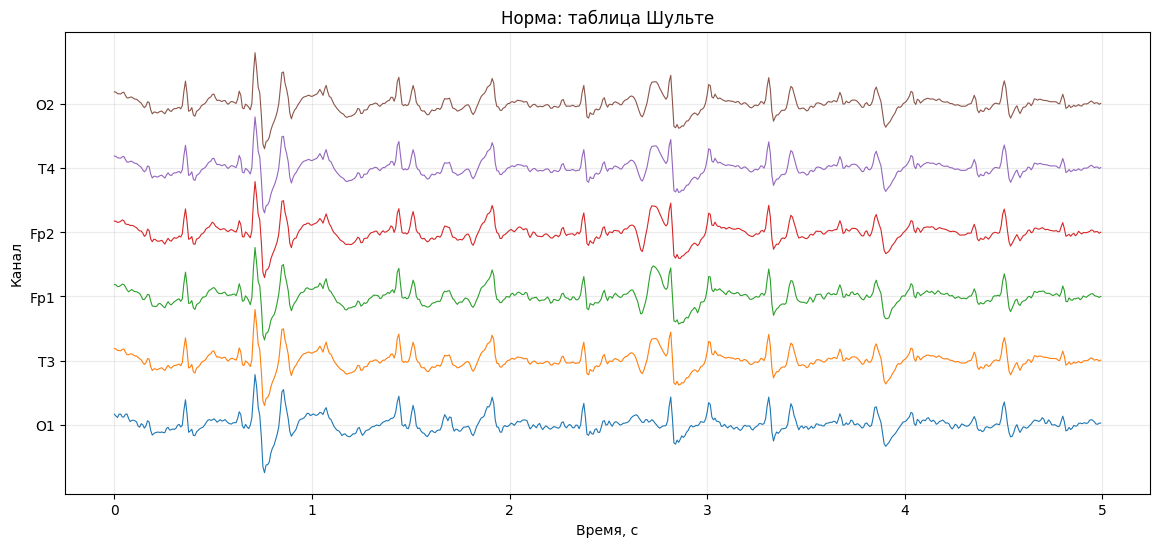

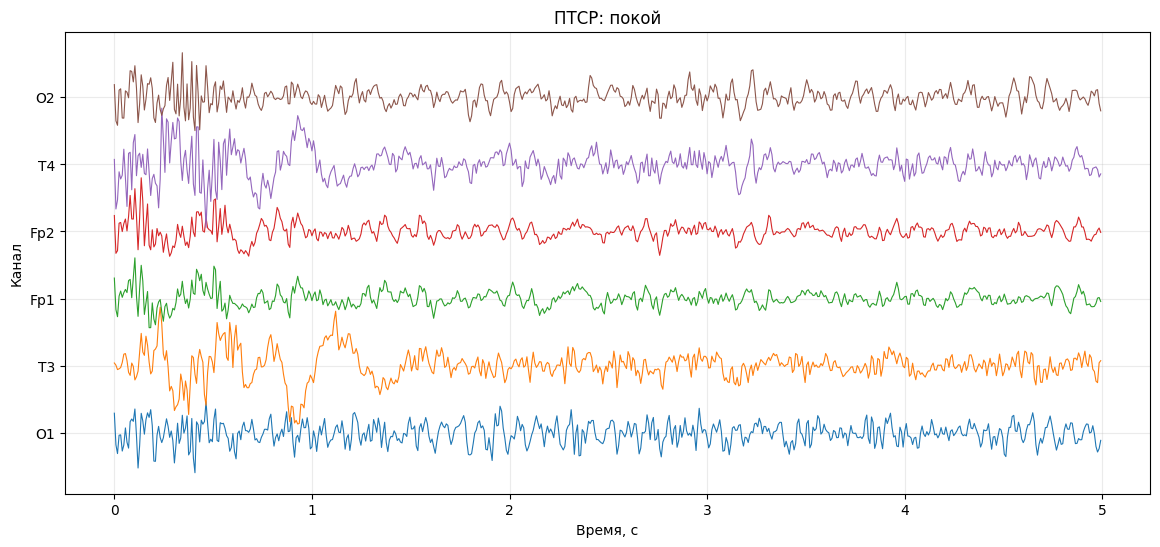

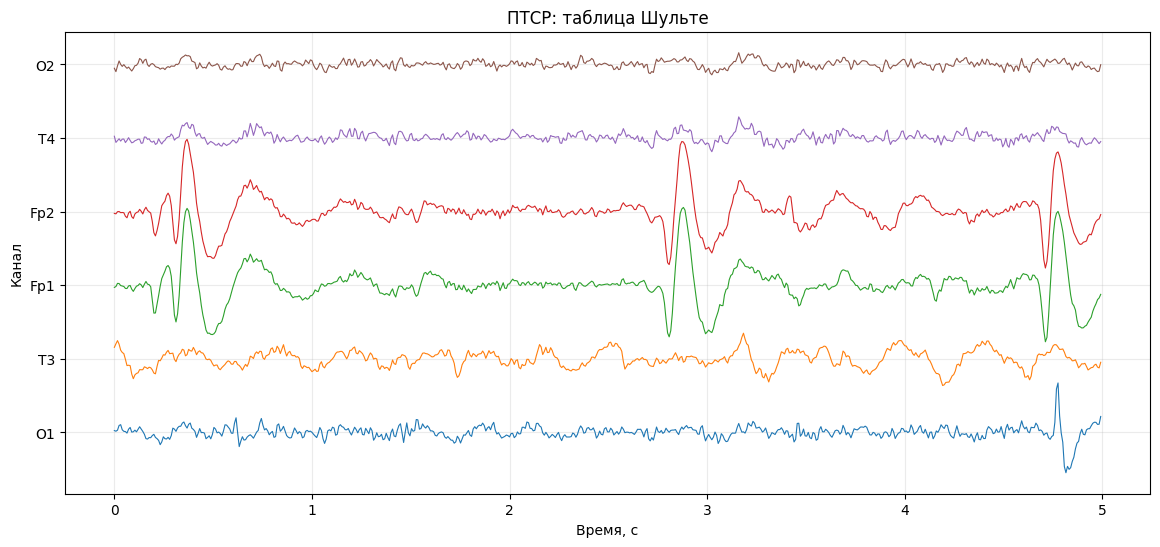

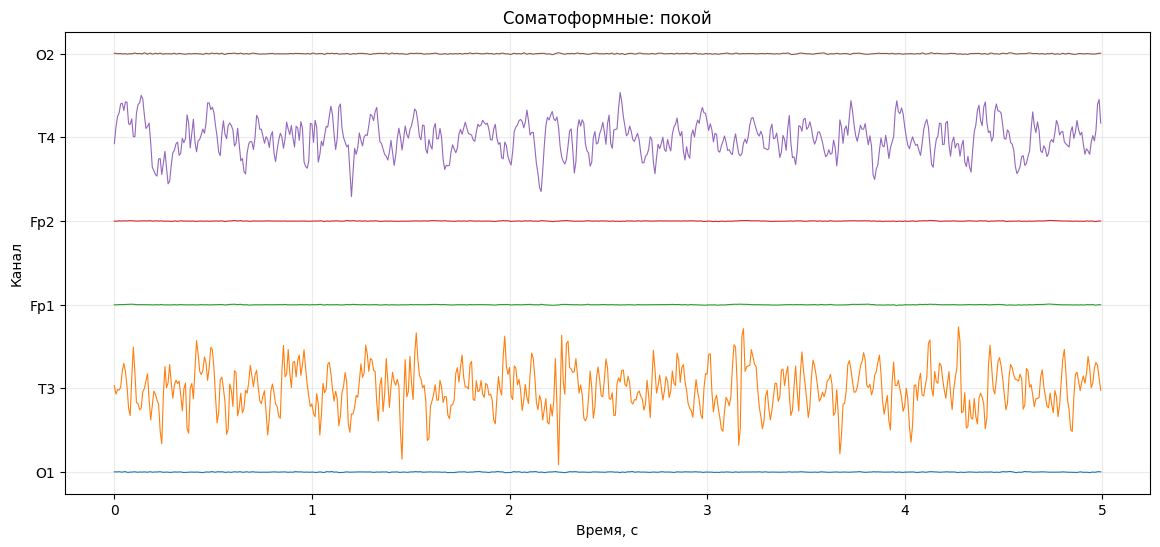

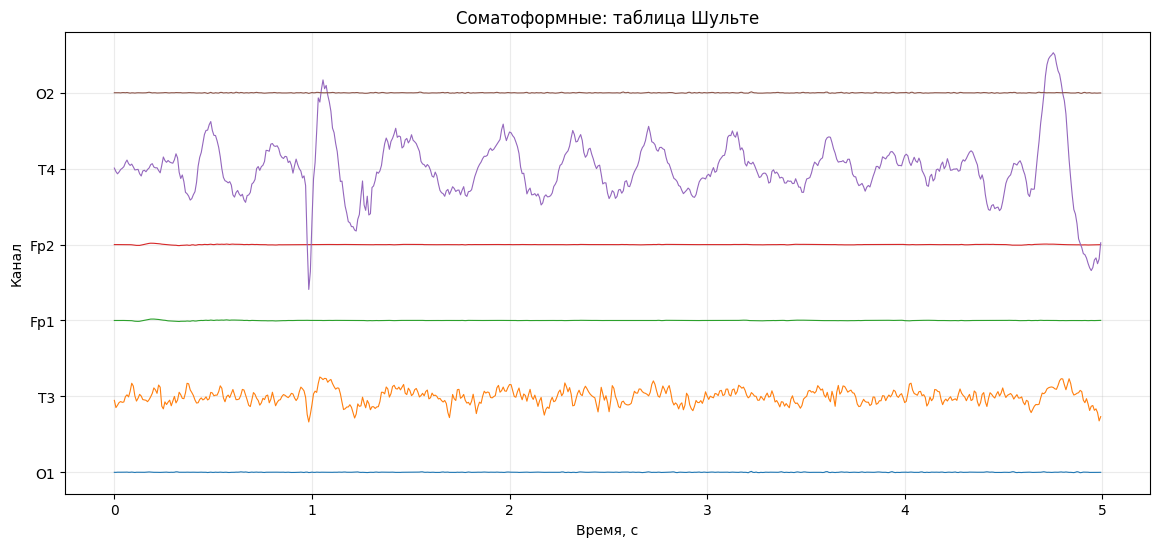

In [20]:
for group in groups:
    #отбираем покой, перебираем каждую группу
    temp = df_files[(df_files['group'] == group) & (df_files['file_type'] == 'Покой')]

    if len(temp) > 0:
        row = temp.iloc[0]
        plot_eeg_example(row['path'], f'{group}: покой')
    #отбираем выполнение таблиц Шульте
    temp = df_files[(df_files['group'] == group) & (df_files['file_type'] == 'Шульте')]
    if len(temp) > 0:
        row = temp.iloc[0]
        plot_eeg_example(row['path'], f'{group}: таблица Шульте')

Были рассмотрены пятисекундные фрагменты записей покоя и выполнения таблицы Шульте для одного испытуемого из каждой диагностической группы. В представленных примерах видны различия формы и амплитуды сигнала между отдельными каналами, а также кратковременные резкие изменения амплитуды. Особенно заметна неоднородность между каналами в примере из группы соматоформных расстройств, височные отведения имеют больший размах, из-за чего остальные каналы на общей шкале выглядят практически плоскими. Поскольку представлены единичные записи, данные графики используются прежде всего для визуального контроля качества сигнала и не используются для выводов о характерных EEG-различиях между диагностическими группами

**Анализ времени выполнения таблиц Шульте**

Количество  Среднее  Стд_откл   Мин   Макс
group         file_type                                            
Норма         Покой              90     62.4       7.3  60.0  114.0
              Шульте            358     49.5      26.2  17.0  272.0
ПТСР          Покой              25     57.1      10.0  35.0   66.0
              Шульте            125     61.6      23.9   8.0  123.0
Соматоформные Покой              74     64.5      12.3  32.0  121.0
              Шульте            365     45.8      16.0   1.0  142.0

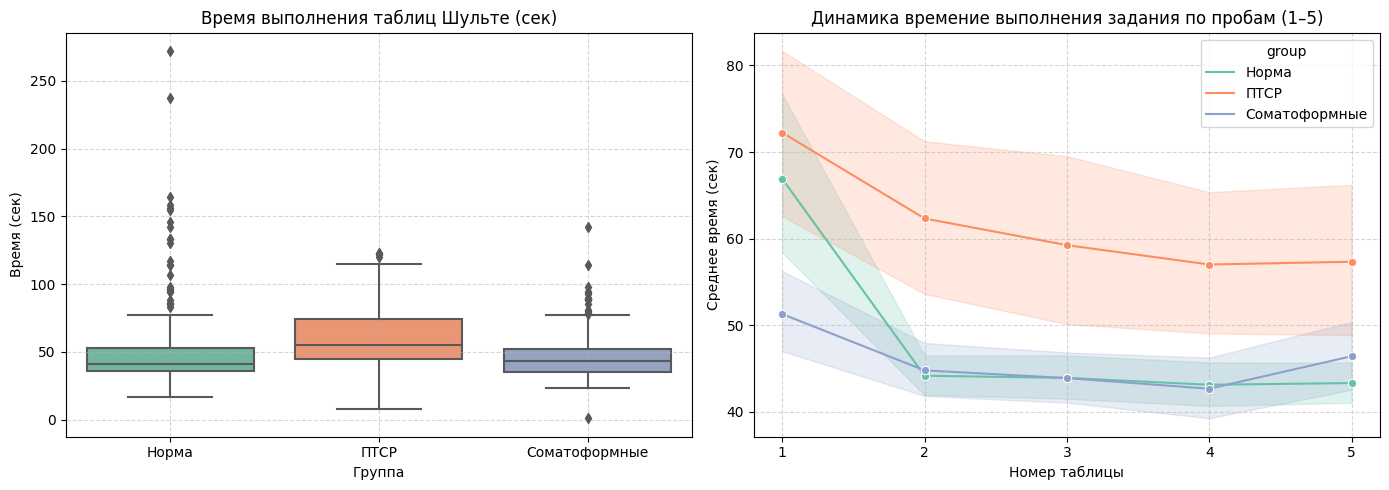

In [21]:
#в данном разделе хотели сравнить время выполнения таблиц Шульте 
duration_summary = (
    df_files
    .groupby(['group', 'file_type'])['duration_sec'] #сначала отбираем по диагностической группе, после по типу записи (покой или Шульте)
    .agg(
        Количество='count',
        Среднее='mean',
        Стд_откл='std',
        Мин='min',
        Макс='max'
    )
    .round(1)
)
#для каждой группы рассчитали описательные статистики 
#выводим получившуюся таблицу
display(duration_summary)
#оставляем только время выполнения с таблицами Шульте
df_schulte = df_files[df_files['file_type'] == 'Шульте'].copy()
df_schulte['task_num'] = (
    df_schulte['file_name']
    .str.extract(r'[-_](\d+)\.edf$', expand=False)
    .astype(int)
)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_schulte, x='group', y='duration_sec', palette='Set2')
plt.title('Время выполнения таблиц Шульте (сек)')
plt.xlabel('Группа')
plt.ylabel('Время (сек)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
sns.lineplot(data=df_schulte, x='task_num', y='duration_sec', hue='group', marker='o', palette='Set2')
plt.title('Динамика времение выполнения задания по пробам (1–5)')
plt.xlabel('Номер таблицы')
plt.ylabel('Среднее время (сек)')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
display(df_schulte[['file_name', 'task_num']].head(20))

,file_name,task_num
0,T-1.edf,1
2,T-1.edf,1
4,T-1.edf,1
6,T-1.edf,1
8,T-1.edf,1
10,Т-1.edf,1
12,Т-1.edf,1
14,Т-1.edf,1
16,Т-1.edf,1
18,Т-1.edf,1


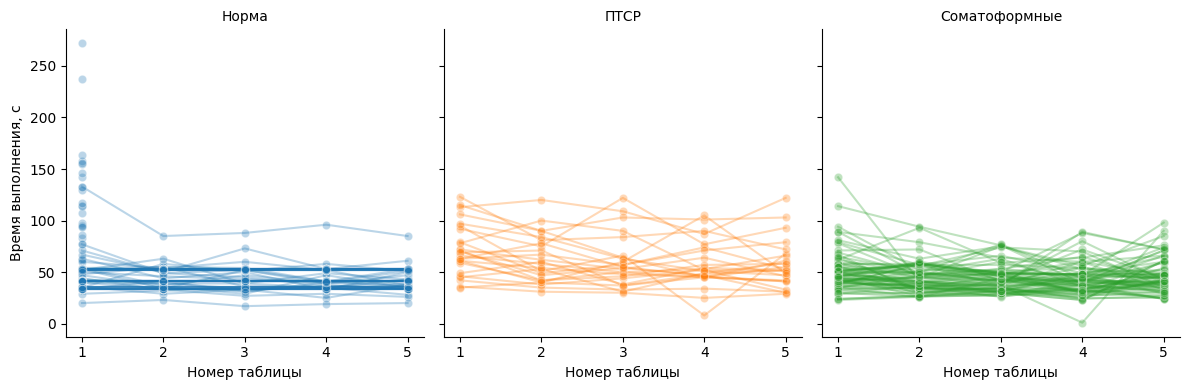

In [23]:
#решили посмотреть на индивидуальную динамику выполнения таблиц Шульте
g = sns.relplot(
    data=df_schulte,
    x='task_num',
    y='duration_sec',
    col='group',
    hue='group',
    kind='line',
    marker='o',
    alpha=0.3,
    legend=False,
    col_wrap=3,
    height=4,
    estimator=None,      
    units='subject_id'
)

g.set_axis_labels(
    'Номер таблицы',
    'Время выполнения, с'
)

g.set_titles('{col_name}')

Для записей покоя для группы "Норма" получены довольно стабильные показатели, стандартное отклонение составляет всего 0.8 секунды, у клинических групп разброс гораздо больше, особенно выделяется группа "Соматоформные", где разброс между минимальным и максимальным значениями доходит до 90 с. 
 Результаты выполнения таблиц Шульте: в группе "Норма" средняя длительность составляла 44.2 с, в группе "ПТСР"= 61.6 с, в группе соматоформных расстройств = 45.8 с. По боксплоту видно, что распределение группы "ПТСР" смещено в сторону более длительного выполнения. Во всех 3 группах первое выполнение в среднем самое длинное, скорее всего после него наблюдается привыкание/адаптация к заданию. 
  Кроме того, были визуализированы изменения времени выполнения пяти проб для каждого испытуемого. Во всех группах у многих участников первая проба занимает больше времени, после чего время выполнения чаще снижается или стабилизируется. В группе ПТСР в целом наблюдаются более высокие значения времени выполнения и больший разброс индивидуальных траекторий. При этом характер изменения времени от первой к пятой пробе различается между участниками. 

**Анализ аномальных значений и амплитудных разбросов ЭЭГ-каналов**

In [24]:
#далее посмотрели, есть ли выбросы в данных (экстремальные значения)
def detect_iqr_outliers(group_df, column='duration_sec'):

    q1 = group_df[column].quantile(0.25)
    q3 = group_df[column].quantile(0.75)

    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    result = group_df[
        (group_df[column] < lower) |
        (group_df[column] > upper)
    ].copy()
    result['lower_limit'] = lower
    result['upper_limit'] = upper
    return result
duration_outliers = (
    df_files
    .groupby(['group', 'file_type'], group_keys=False)
    .apply(detect_iqr_outliers)
)

display(duration_outliers[['subject_id','group','file_name','file_type','duration_sec','lower_limit','upper_limit']].sort_values('duration_sec', ascending=False).head(5))

,subject_id,group,file_name,file_type,duration_sec,lower_limit,upper_limit
44,А035_69,Норма,Т-1.edf,Шульте,272.0,10.5,78.5
24,А011_69,Норма,Т-1.edf,Шульте,237.0,10.5,78.5
40,А022_68,Норма,Т-1.edf,Шульте,164.0,10.5,78.5
16,А007_68,Норма,Т-1.edf,Шульте,158.0,10.5,78.5
26,А012_70,Норма,Т-1.edf,Шульте,156.0,10.5,78.5


In [25]:
print(
    duration_outliers
    .groupby(['group', 'file_type'])
    .size()
)

group          file_type
Норма          Покой         4
               Шульте       25
ПТСР           Покой         7
               Шульте        4
Соматоформные  Покой        13
               Шульте       18
dtype: int64


С помощью межквартильного размаха были найдены данные, отличающиеся от типичной деятельности внутри каждой диагностической группы. Такие значения рассматривались как объекты для дополнительной проверки, а не автоматически удалялись, поскольку необычная длительность выполнения таблиц Шульте может отражать реальные индивидуальные различия в скорости выполнения задания.

In [26]:
artifact_stats = []
for idx, row in df_files.iterrows():
    try:
        raw = mne.io.read_raw_edf(
            row['path'],
            preload=True,
            verbose="Error")
        #перевод в мкВ
        raw.pick(EEG_CHANNELS)
        data_uv = raw.get_data() * 1e6
        #максимальный размах между минимальным и максимальным значениями, отдельно для каждого канала во времени
        peak_to_peak = np.ptp(data_uv, axis=1)
        #стандартное отклонение
        channel_std = np.std(data_uv, axis=1)
        #доля очень больших значений
        #300 мкВ = эвристический QC-порог, а не физиологическая граница
        high_amp_fraction = (
            np.abs(data_uv) > 300
        ).mean()
        artifact_stats.append({
            'subject_id': row['subject_id'],
            'group': row['group'],
            'file_name': row['file_name'],
            'file_type': row['file_type'],
            'median_ptp_uv':
                np.median(peak_to_peak),
            'max_ptp_uv':
                np.max(peak_to_peak),
            'median_std_uv':
                np.median(channel_std),
            'high_amp_fraction':
                high_amp_fraction
        })
#в результате сохраняем медианный пик среди 6 каналов
    except Exception as e:
        print('Ошибка:', row['path'], e)


df_artifacts = pd.DataFrame(artifact_stats)

In [27]:
display(
    df_artifacts.groupby(
        ['group', 'file_type']
    )[
        [
            'median_ptp_uv',
            'max_ptp_uv',
            'median_std_uv',
            'high_amp_fraction'
        ]
    ]
    .median()
    .round(2)
)

median_ptp_uv  max_ptp_uv  median_std_uv  \
group         file_type                                             
Норма         Покой              71.53      386.02           8.42   
              Шульте            156.07      460.59          15.12   
ПТСР          Покой             174.84      319.46          14.67   
              Шульте            188.57      483.83          16.07   
Соматоформные Покой             299.25     4105.50          19.73   
              Шульте            386.00     3730.00          29.13   

                         high_amp_fraction  
group         file_type                     
Норма         Покой                   0.00  
              Шульте                  0.00  
ПТСР          Покой                   0.00  
              Шульте                  0.00  
Соматоформные Покой                   0.02  
              Шульте                  0.01

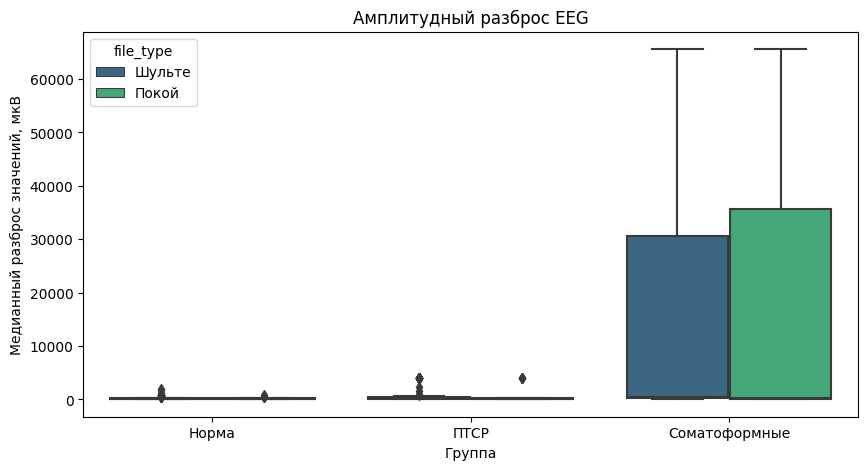

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_artifacts, x='group', y='median_ptp_uv', hue='file_type', palette='viridis')

plt.title('Амплитудный разброс EEG')
plt.xlabel('Группа')
plt.ylabel('Mедианный разброс значений, мкВ')

plt.show()

In [29]:
channel_quality = []
#перебираем все успешно прочитанные EDF-файлы
for idx, row in df_files.iterrows():
    try:
        #загружаем EEG
        raw = mne.io.read_raw_edf(row['path'], preload=True, verbose='ERROR')
        #оставляем только 6 нужных EEG-каналов
        raw.pick(EEG_CHANNELS)
        #переводим значения из вольт в микровольты
        data_uv = raw.get_data() * 1e6

        #рассматриваем каждый канал отдельно
        for i, ch in enumerate(raw.ch_names):
            signal = data_uv[i]
            #сохраняем показатели качества для каждого канала
            channel_quality.append({
                'subject_id': row['subject_id'],
                'group': row['group'],
                'file_name': row['file_name'],
                'file_type': row['file_type'],
                'channel': ch,
                #полный амплитудный размах канала
                'ptp_uv': np.ptp(signal),
                #стандартное отклонение сигнала
                'std_uv': np.std(signal),
                #доля отсчетов с амплитудой выше 300 мкВ
                'high_amp_fraction': (
                    np.abs(signal) > 300
                ).mean()
            })
    except Exception as e:
        print('Ошибка:', row['path'], e)

#создаем таблицу с результатами
df_channel_quality = pd.DataFrame(channel_quality)

In [30]:
#амплитудный разброс для каждого канала отдельно, чтобы посмотреть, который из них вносит вклад в большой амплитудный разброс для соматоформных участников
channel_ptp_summary = (
    df_channel_quality
    .groupby(['group', 'channel'])['ptp_uv']
    .median()
    .unstack()
    .round(1)
)
display(channel_ptp_summary)

channel,Fp1,Fp2,O1,O2,T3,T4
group,,,,,,
Норма,154.1,111.1,183.6,118.2,395.3,140.5
ПТСР,244.9,251.1,169.3,148.1,213.3,165.8
Соматоформные,373.0,392.0,350.0,321.0,1129.0,903.0


Количественный анализ подтвердил разнородность амплитуд между различными EEG-каналами. Наибольший размах наблюдается в височных отведениях T3 и T4, их значения peak-to-peak примерно в 3 раза превышают значения остальных каналов. При этом доля отсчётов с абсолютной амплитудой выше 300 мкВ остаётся относительно небольшой, в том числе в соматоформной группе. Это показывает, что высокие амплитуды могут быть сосредоточены в отдельных каналах и временных участках, а не присутствовать постоянно во всей записи. 

**Конфаундеры**
1) возраст, является потенциальным конфаундером, поскольку возрастной состав групп различается. Контрольная группа включает мужчин 18–55 лет, тогда как группа ПТСР ограничена возрастом 18–25 лет, а соматоформная группа — 18–45 лет. Кроме того, индивидуальный возраст известен только для группы «Норма». Поэтому полностью отделить влияние возраста от влияния диагностической группы на имеющихся данных невозможно
2) пол также необходимо учитывать при интерпретации результатов. Группы «Норма» и "ПТСР" состоят из мужчин, тогда как соматоформная группа включает участников обоих полов. Следовательно, при сравнении с соматоформной группой часть наблюдаемых различий потенциально может быть связана с различиями в половом составе выборки
3) частота дискретизации и особенности амплитудного масштаба EEG рассматриваются в качестве технических конфаундеров. Частота дискретизации варьирует в пределах 123–127 Гц и распределена между группами неравномерно. Кроме того, выявлен повышенный амплитудный размах каналов T3 и T4. Поэтому технические характеристики записи не должны использоваться моделью как диагностические признаки и должны учитываться на этапе предобработки


**Первичные гипотезы**
1. Время выполнения таблиц Шульте может отражать различия между диагностическими группами, группа "ПТСР" характеризовалась большей средней длительностью выполнения задания, поэтому в дальнейшем будут исследованы как абсолютное время выполнения, так и его изменение от первой к пятой пробе
2. Характер изменения EEG при переходе от состояния покоя к выполнению таблиц Шульте, а также в ходе последовательных проб 1-5, может также различаться между диагностическими группами. Поэтому в дальнейшем планируется исследовать изменения EEG относительно состояния покоя и динамику EEG от первой к последней пробе
3. Различия между группами могут проявляться в спектральных характеристиках EEG, прежде всего в относительной и абсолютной мощности основных частотных диапазонов. Поэтому на следующем этапе будут исследованы дельта, тета, альфа и бета-ритмы отдельно для доступных EEG-каналов, а также их изменение между покоем и выполнением задания

[1]Butt M, Espinal E, Aupperle RL, Nikulina V and Stewart JL (2019) The Electrical Aftermath: Brain Signals of Posttraumatic Stress Disorder Filtered Through a Clinical Lens. Front. Psychiatry 10:368. doi: 10.3389/fpsyt.2019.00368

[2]Begić, D., Hotujac, L., & Jokić-Begić, N. (2001). Electroencephalographic comparison of veterans with combat-related post-traumatic stress disorder and healthy subjects. International journal of psychophysiology : official journal of the International Organization of Psychophysiology, 40(2), 167–172. https://doi.org/10.1016/s0167-8760(00)00153-7 